# Reservoir Computing Using Polynomial Features: Chebyshev Polynomials

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import pandas as pd
import csv

In [2]:
# Fonts
csfont = {'fontname':'Palatino Linotype', 'size': 15}
hfont = {'fontname':'Palatino Linotype', 'size': 13}

## Static Task: Approximating a 7th-degree Polynomial

In [3]:
N = 1500

x_min, x_max = -3, 3
x = np.linspace(x_min, x_max, N)

targets = (x - 3)*(x - 2)*(x - 1)*x*(x + 1)*(x + 2)*(x + 3)

In [4]:
def scaling(x, x_min, x_max, res = 'chebyshev'):
    # scale input from [x_min, x_max] to [-1, 1]
    if res == 'chebyshev':
        return 2 * (x - x_min) / (x_max - x_min) - 1
    elif res == 'tent':
        return (x - x_min)/(x_max - x_min)
        
def chebyshev(x, M):
    N = len(x)
    T = np.zeros((M + 1, N))
    
    T[0, :] = 1.0
    T[1, :] = x
    
    for i, x_val in enumerate(x):
        A = np.array([[2*x_val, -1],
                      [1, 0]])
        
        # state vector
        z = np.array([x_val, 1.0])  # z_1 = [T_1(x), T_0(x)]
        
        for n in range(2, M + 1):
            z = A @ z
            T[n, i] = z[0]  # taking first comp
    return T

x_scaled = scaling(x, x_min, x_max, res = 'chebyshev')

In [7]:
# logistic map
def logistic(r, x):
    return r * x * (1 - x)

In [8]:
# tent reservoir trial too
def tentmap(r, x):
    if x < 0.5:
        return r*x
    else:
        return r*(1 - x)
    
def tent(x, M, r = 2.0):
    N = len(x)
    T = np.zeros((M + 1, N))
    
    for i, xvalues in enumerate(x):
        state = xvalues
        T[0, i] = state
        
        for n in range(1, M + 1):
            state = tentmap(r, state)
            T[n, i] = state
    
    return T

In [9]:
# we want to find the best M value, i.e., degree of the polynomial

M_values = range(5, 20)
results = []

for i in M_values:
    Phi = chebyshev(x_scaled, i)
    w = targets @ np.linalg.pinv(Phi)
    prediction = w @ Phi

    delta = np.sqrt(np.mean(np.sum((prediction - targets)**2)))
    log_del = -np.log10(delta) if delta > 0 else np.inf

    # 8th and 9th Chebyshev Coefficients
    C_8 = w[8] if len(w) > 8 else np.nan
    C_9 = w[9] if len(w) > 9 else np.nan

    results.append({'M': i,
        'delta': delta,
        '-log10(delta)': log_del,
        'C_8': C_8,
        'C_9': C_9})
    
    print(f'M: {round(i, 2)}\n', f'Delta: {round(delta, 3)}\n', 
          f'-log10(delta): {round(log_del, 2)}\n', f'C_8: {round(C_8, 3)}\n',
          f'C_8: {round(C_8, 3)}')
    
df = pd.DataFrame(results)
df.to_csv(r'C:\Users\Sahaana V\Desktop\ASP\static_task_M_coeffs.csv', index = False)

M: 5
 Delta: 819.455
 -log10(delta): -2.91
 C_8: nan
 C_8: nan
M: 6
 Delta: 819.455
 -log10(delta): -2.91
 C_8: nan
 C_8: nan
M: 7
 Delta: 0.0
 -log10(delta): 11.88
 C_8: nan
 C_8: nan
M: 8
 Delta: 0.0
 -log10(delta): 11.85
 C_8: -0.0
 C_8: -0.0
M: 9
 Delta: 0.0
 -log10(delta): 11.46
 C_8: 0.0
 C_8: 0.0
M: 10
 Delta: 0.0
 -log10(delta): 11.72
 C_8: -0.0
 C_8: -0.0
M: 11
 Delta: 0.0
 -log10(delta): 11.63
 C_8: 0.0
 C_8: 0.0
M: 12
 Delta: 0.0
 -log10(delta): 11.32
 C_8: 0.0
 C_8: 0.0
M: 13
 Delta: 0.0
 -log10(delta): 11.58
 C_8: 0.0
 C_8: 0.0
M: 14
 Delta: 0.0
 -log10(delta): 11.63
 C_8: -0.0
 C_8: -0.0
M: 15
 Delta: 0.0
 -log10(delta): 11.58
 C_8: -0.0
 C_8: -0.0
M: 16
 Delta: 0.0
 -log10(delta): 11.51
 C_8: -0.0
 C_8: -0.0
M: 17
 Delta: 0.0
 -log10(delta): 11.56
 C_8: -0.0
 C_8: -0.0
M: 18
 Delta: 0.0
 -log10(delta): 11.63
 C_8: 0.0
 C_8: 0.0
M: 19
 Delta: 0.0
 -log10(delta): 11.69
 C_8: 0.0
 C_8: 0.0


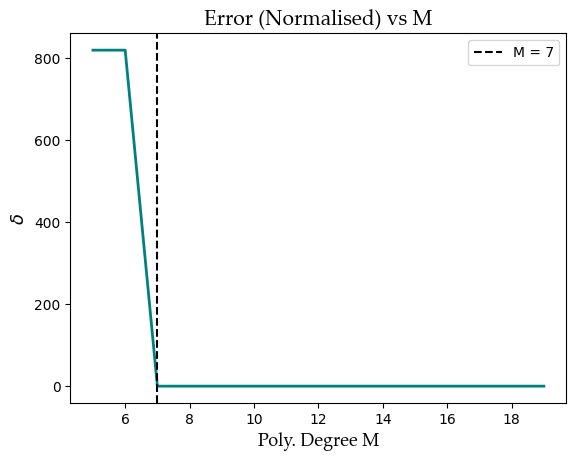

In [10]:
# delta vs M
plt.plot(df['M'], df['delta'], '-', linewidth = 2, markersize = 8, color = 'teal')
plt.xlabel('Poly. Degree M', **hfont)
plt.ylabel(r'$\delta$', **hfont)
plt.axvline(x = 7, linestyle = '--', color = 'k', label = 'M = 7')
plt.title('Error (Normalised) vs M', **csfont)
plt.legend()
plt.show()

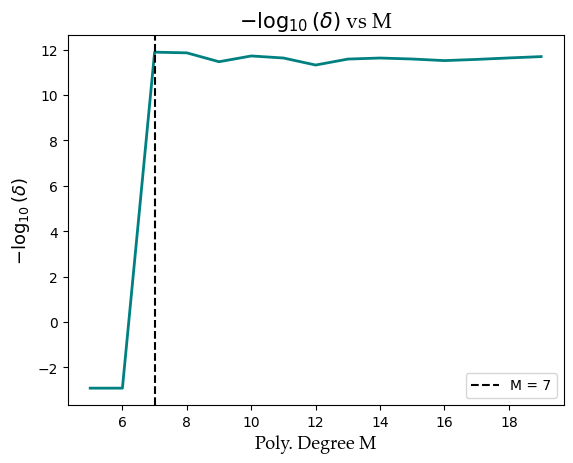

In [11]:
# -log10(delta) vs M
plt.plot(df['M'], df['-log10(delta)'], '-', linewidth = 2, markersize = 8, color = 'teal')
plt.xlabel('Poly. Degree M', **hfont)
plt.ylabel(r'$-\log_{10}(\delta)$', **hfont)
plt.axvline(x = 7, linestyle = '--', color = 'k', label = 'M = 7')
plt.title(r'$-\log_{10}(\delta)$ vs M', **csfont)
plt.legend()
plt.show()

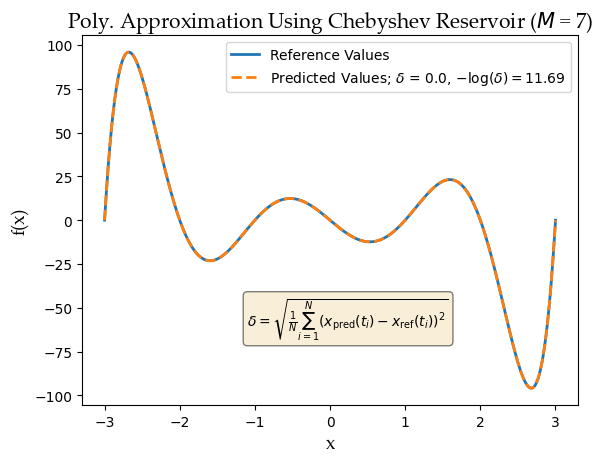

In [12]:
# predictions

# feature matrix
M = 7  # polynomial degree
Phi = chebyshev(x_scaled, M)

_lambda = 1e-8

Phi_Phi_T = Phi @ Phi.T
w = targets @ np.linalg.pinv(Phi)
prediction = w @ Phi
delta = np.sqrt(np.mean(np.sum((prediction - targets)**2)))

plt.plot(x, targets, '-', linewidth = 2, label = 'Reference Values')
plt.plot(x, prediction, '--', linewidth= 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
plt.xlabel('x', **hfont)
plt.ylabel('f(x)', **hfont)
plt.title(r'Poly. Approximation Using Chebyshev Reservoir ($M$ = 7)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
plt.text(-1.1, -60, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} (x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i}))^2}$', bbox = props)
plt.legend()
plt.show()

In [13]:
# calculating roots

f_interp = interp1d(x, prediction, kind ='cubic', fill_value = 'extrapolate')
 
def pred_func(x_val):
    return f_interp(x_val)

initial_guess = np.linspace(x_min, x_max, 15)
roots = fsolve(pred_func, initial_guess)

def unique_roots(roots, tol = 1e-4):
    roots = np.sort(roots)
    unique = [roots[0]]
    for r in roots[1:]:
        if abs(r - unique[-1]) > tol:
            unique.append(r)
    return np.array(unique)

fin_roots = unique_roots(roots)
fin_roots = fin_roots[(fin_roots >= x_min) & (fin_roots <= x_max)]

print('Found roots:', np.round(fin_roots, 6))

Found roots: [-3. -2. -1. -0.  1.  2.  3.]


## Temporal Task: Predicting Dynamics in Lorenz System

In [14]:
x_min, x_max = -20, 20

def lorenz(t, state, sigma = 10, rho = 28, beta = 8/3):
    xt = sigma * (state[1] - state[0])
    yt = state[0] * (rho - state[2]) - state[1]
    zt = state[0] * state[1] - state[2] * beta
    return [xt, yt, zt]

In [16]:
def rc(m, M, alpha, inp, out, res = 'chebyshev'):
    # simulating the lorenz systen and generating states
    dt = 0.01 # time step for euler
    T_steps = 10000 # total time steps
    time = np.linspace(0, T_steps * dt, T_steps) # timestamps for all steps
    state = ([25.0, 18.0, 120.0])
    l_states = []

    for i in range(T_steps):
        # state += dt * np.array(lorenz(time[i], state))
        # l_states.append(state)
        # explicitly unpacking
        dx, dy, dz = lorenz(time[i], state)
        state += dt * np.array([dx, dy, dz])
        l_states.append(state.copy()) # just using state gave same values of lz

    l_states = np.array(l_states) # each row is one time step and each column is an x, y, z value

    lx = l_states[:, inp]
    # print('input:', len(lx))
    lz = l_states[:, out]
    # print('corr values:', len(lz))
    # print('lz:', lz)

    if res == 'chebyshev':
        lx_scaled = scaling(lx, x_min, x_max, res = 'chebyshev')
        T = chebyshev(lx_scaled, M)
        M_1, N = T.shape
    elif res == 'tent':
        lx_scaled = scaling(lx, x_min, x_max, res = 'tent')
        T = tent(lx_scaled, M, r = 2.0)
        M_1, N = T.shape

    m_weights = alpha ** np.arange(m, -1, -1)

    valid_ts = N -m + 1
    Phi = np.zeros((m * (M_1), valid_ts)) 

    col = 0
    for i in range(m - 1, N):
        feat_vec = []
        for l in range(m):
            t_lag = i - (m - 1 - l)
            feats = T[:, t_lag] # features at this time index for this lag l
            weighted_feats = m_weights[l] * feats

            feat_vec.extend(weighted_feats)

        Phi[:, col] = feat_vec
        col += 1

    # print('Phi:', Phi.shape)

    _lambda = 1e-8

    # allocating some part of data for training and testing
    train_i = int(40/dt)
    train_f = int(49.99/dt)
    pred_i = int(50/dt) # values in the paper

    # adjusting indices for memory as first valid pred is at m- 1
    train_i_corr = train_i - (m - 1)
    train_f_corr = train_f - (m - 1)
    pred_i_corr = pred_i - (m - 1)

    Phi_train = Phi[:, train_i_corr:train_f_corr]
    v_train = lz[train_i:train_f]

    weight_matrix = np.linalg.solve(Phi_train @ Phi_train.T + _lambda * np.eye(m * (M + 1)), Phi_train @ v_train)
    # weight_matrix = v_train @ np.linalg.pinv(Phi_train)

    # predicting on new data
    Phi_test = Phi[:, pred_i_corr:]
    v_test = lz[pred_i:]
    t_test = time[pred_i:]

    pred = weight_matrix @ Phi_test
    delta_norm = np.sqrt(np.mean(((pred - v_test)/v_test)**2))
    log_del = -np.log10(delta_norm) if delta_norm > 0 else np.inf
    return pred, v_test, t_test, log_del, delta_norm

### z(t) from x(t)

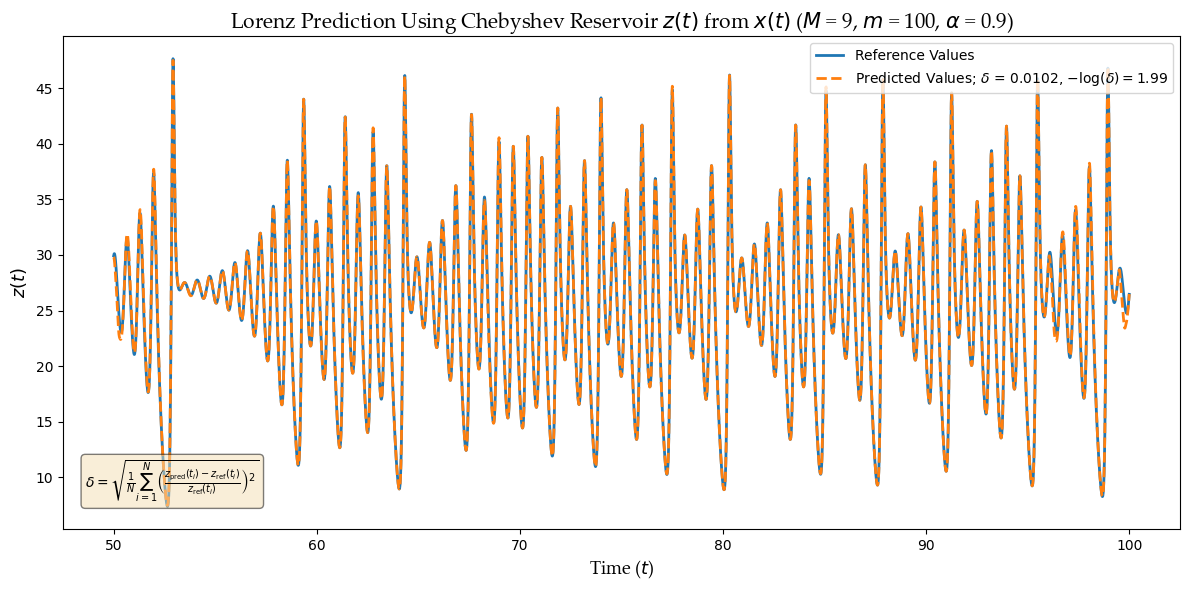

In [17]:
# running
# (m, M, alpha, input index, output index)
pred, v_test, t_test, log_del, delta = rc(100, 9, 0.9, 0, 2)

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$z(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Chebyshev Reservoir $z(t)$ from $x(t)$ ($M$ = 9, $m$ = 100, $\alpha$ = 0.9)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


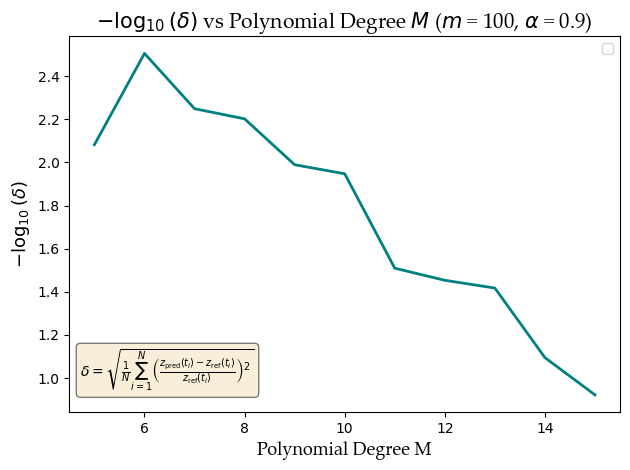

In [18]:
# delta vs M

M_values = range(5, 16)
'''[5, 16] as with m = 100 and M = 15, the feature dim is m(M + 1) = 1600 and 
our training set has 10/0.01 = 1000 pts so we have more features than data and going
beyond 15 means overfitting, before 5 we will have simple fetures like linear 
and quadratic'''
m = 100
alpha = 0.9
'''for a = 0.9 and m = 100, lag 0 we have weight 1 and by lag 100, 0.9^100 = 2.65e-5
which is negligible'''

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 0, 2)
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


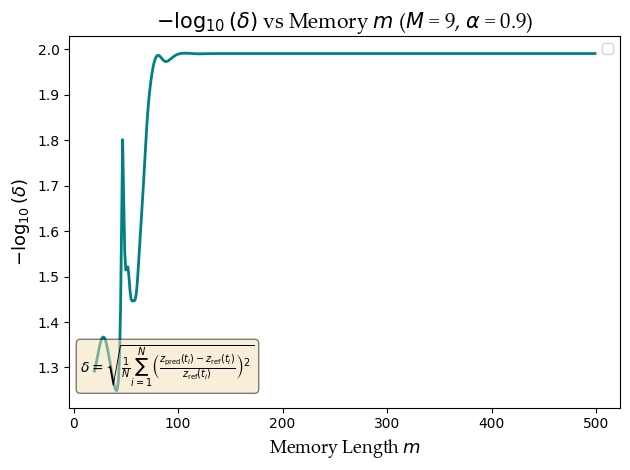

In [20]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'del_vs_m_zx.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


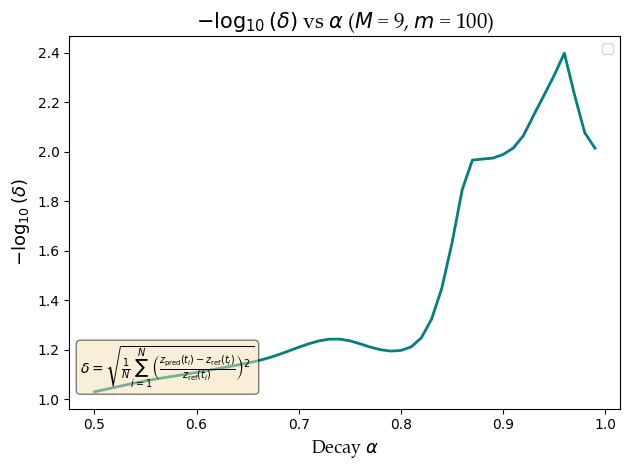

In [21]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'del_vs_a_zx.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### x(t) from z(t)

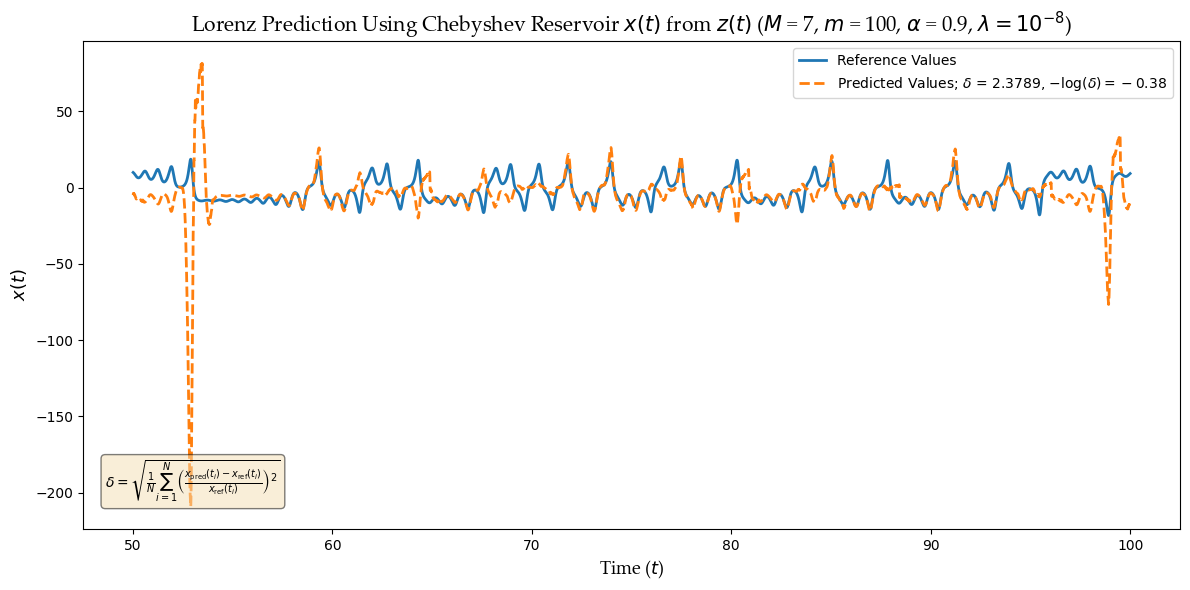

In [24]:
pred, v_test, t_test, log_del, delta = rc(100, 7, 0.9, 2, 0)

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$x(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Chebyshev Reservoir $x(t)$ from $z(t)$ ($M$ = 7, $m$ = 100, $\alpha$ = 0.9, $\lambda = 10^{-8}$)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


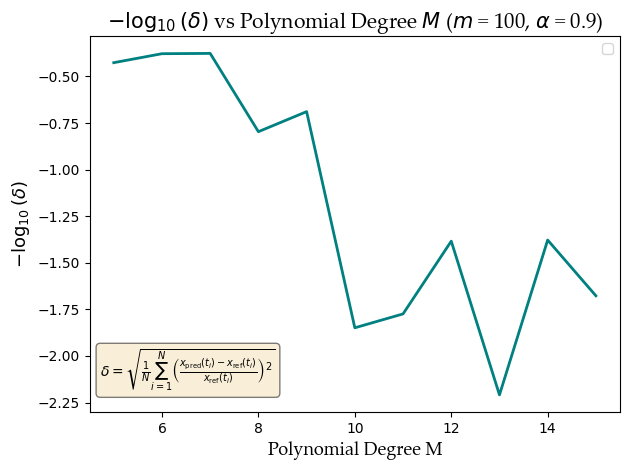

In [25]:
# delta vs M

M_values = range(5, 16)
'''[5, 16] as with m = 100 and M = 15, the feature dim is m(M + 1) = 1600 and 
our training set has 10/0.01 = 1000 pts so we have more features than data and going
beyond 15 means overfitting, before 5 we will have simple fetures like linear 
and quadratic'''
m = 100
alpha = 0.9
'''for a = 0.9 and m = 100, lag 0 we have weight 1 and by lag 100, 0.9^100 = 2.65e-5
which is negligible'''

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 2, 0)
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


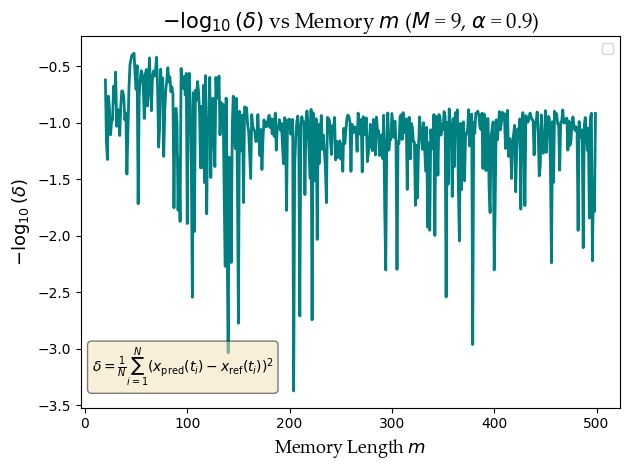

In [27]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'del_vs_m_xz.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \frac{1}{N}\sum_{i = 1}^{N} (x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i}))^2$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


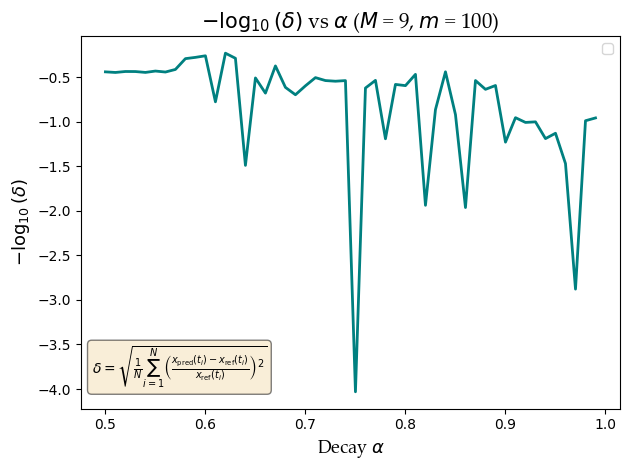

In [28]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'del_vs_a_xz.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### y(t) from x(t)

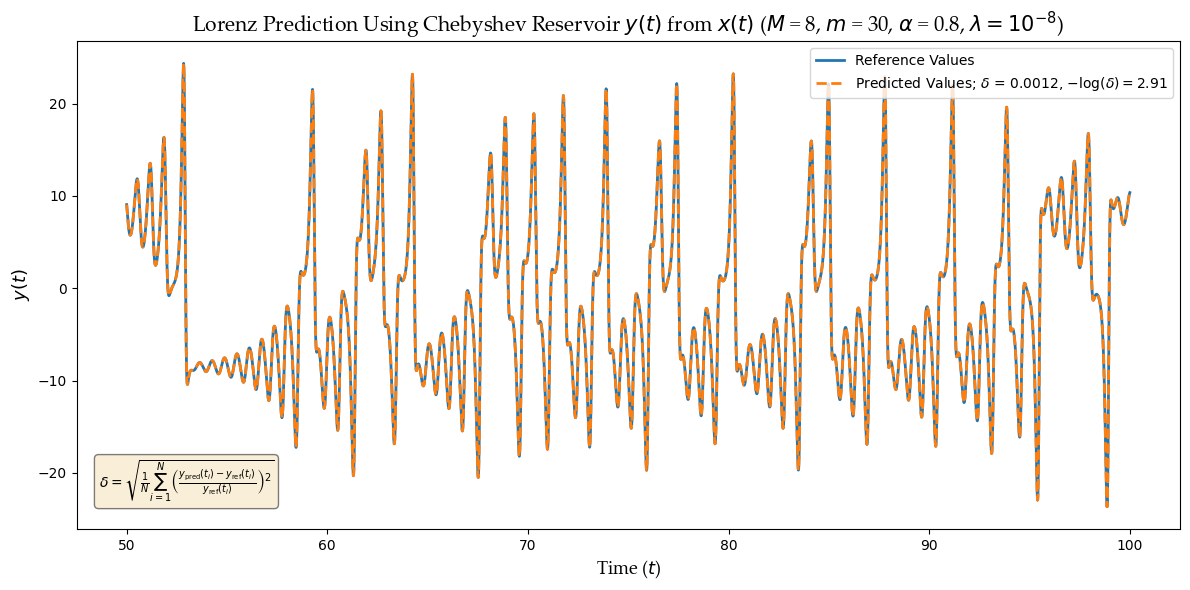

In [29]:
pred, v_test, t_test, log_del, delta = rc(30, 8, 0.8, 0, 1)

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$y(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Chebyshev Reservoir $y(t)$ from $x(t)$ ($M$ = 8, $m$ = 30, $\alpha$ = 0.8, $\lambda = 10^{-8}$)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


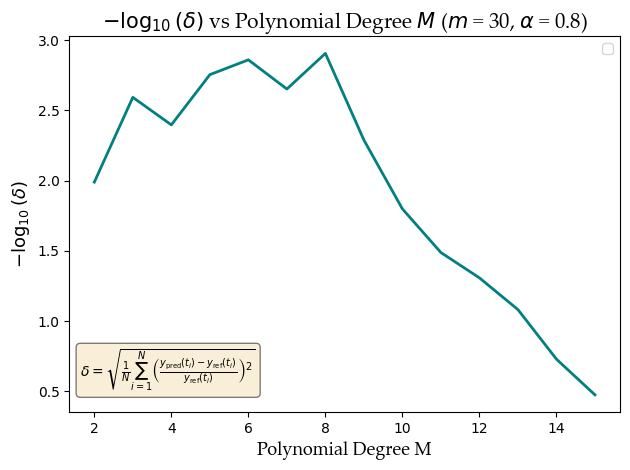

In [30]:
# delta vs M

M_values = range(2, 16)
m = 30
alpha = 0.8

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 0, 1)
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 30, $\alpha$ = 0.8)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


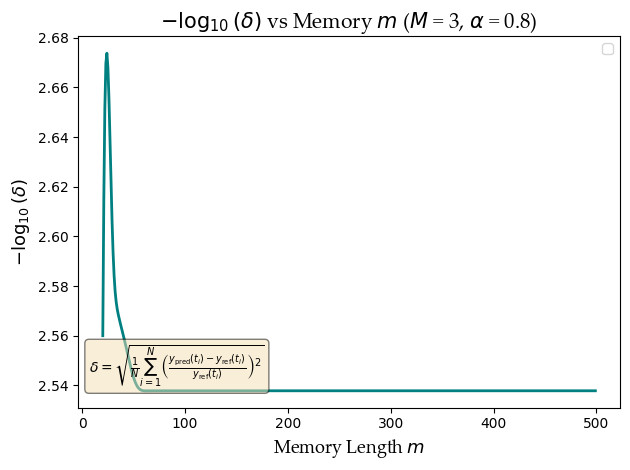

In [31]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'del_vs_m_yx.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 3, $\alpha$ = 0.8)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

In [ ]:
mlist = df['m']
for i in mlist:
    print(i)

# 2.673753985247062
# 24

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


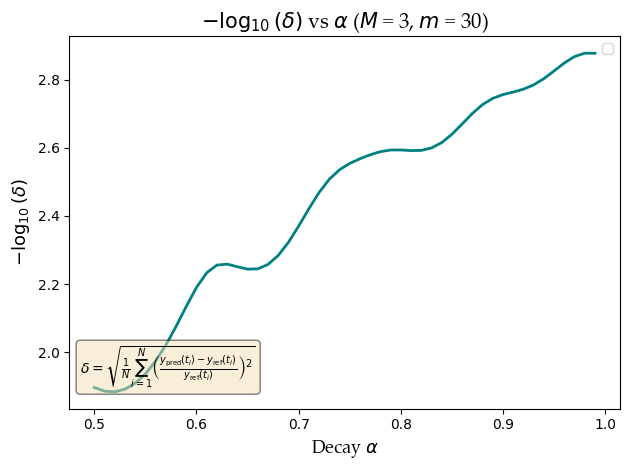

In [32]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'del_vs_a_yx.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 3, $m$ = 30)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


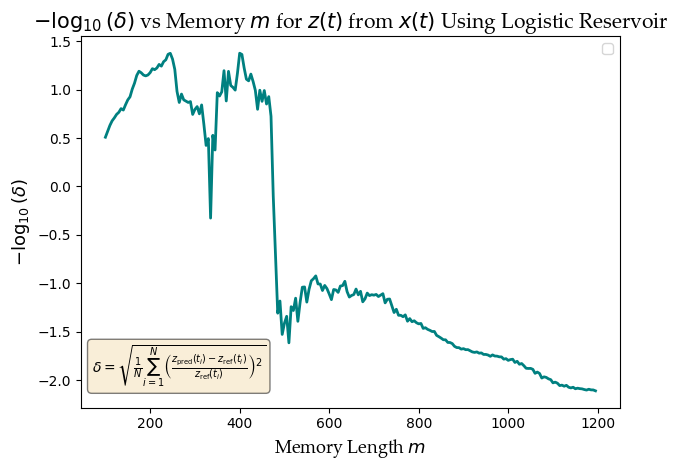

In [33]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'logistic_error_vs_memory2.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ for $z(t)$ from $x(t)$ Using Logistic Reservoir', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### x(t) from y(t)

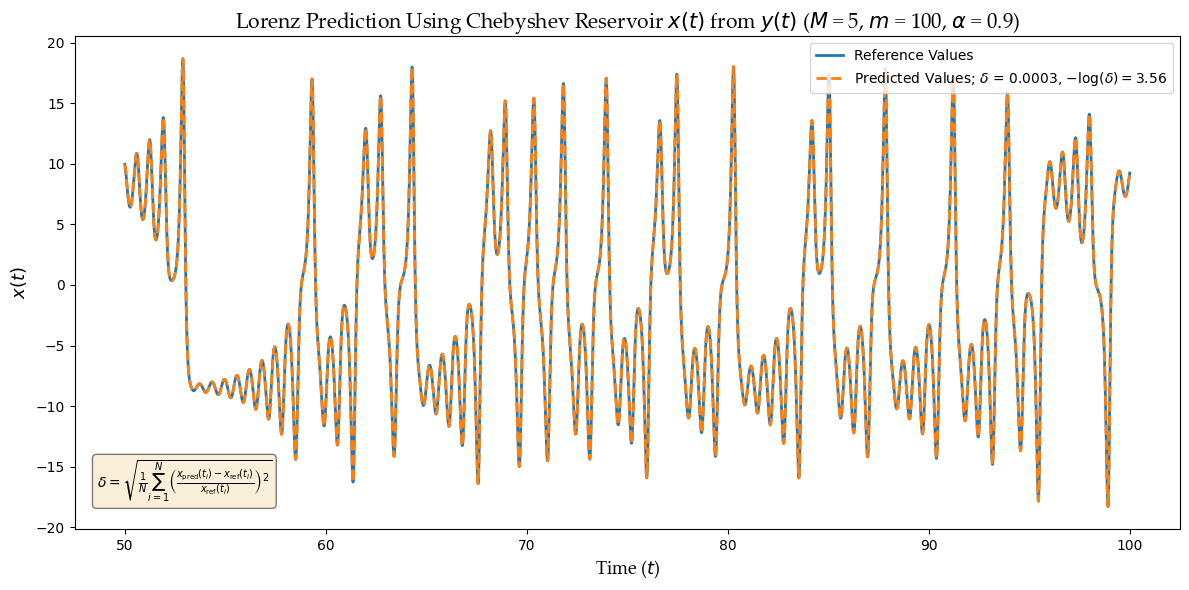

In [34]:
pred, v_test, t_test, log_del, delta = rc(100, 5, 0.9, 1, 0)

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$x(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Chebyshev Reservoir $x(t)$ from $y(t)$ ($M$ = 5, $m$ = 100, $\alpha$ = 0.9)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


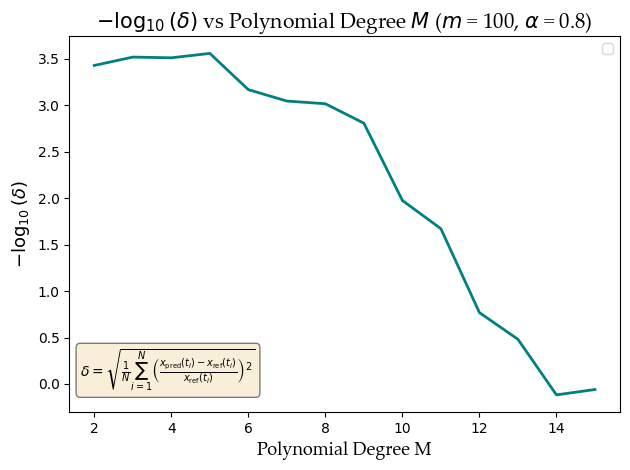

In [35]:
# delta vs M

M_values = range(2, 16)
m = 100
alpha = 0.9

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 1, 0)
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.8)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


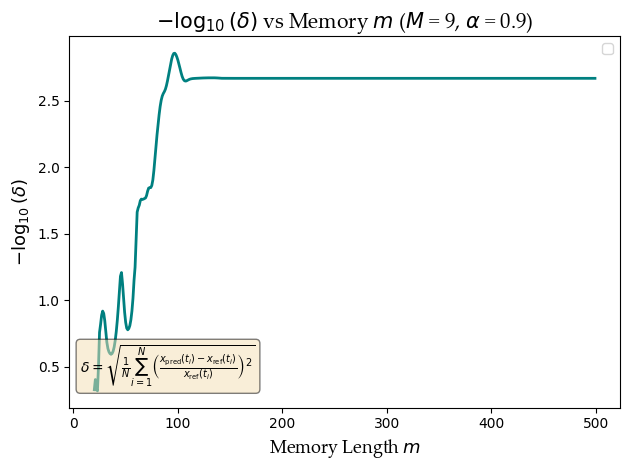

In [36]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'del_vs_m_xy.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


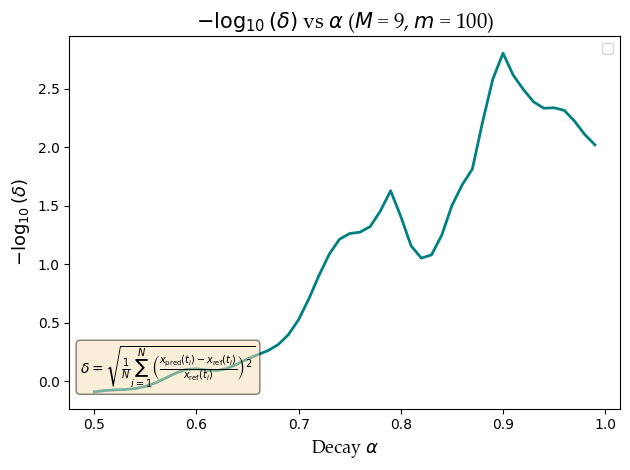

In [37]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'del_vs_a_xy.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### z(t) from y(t)

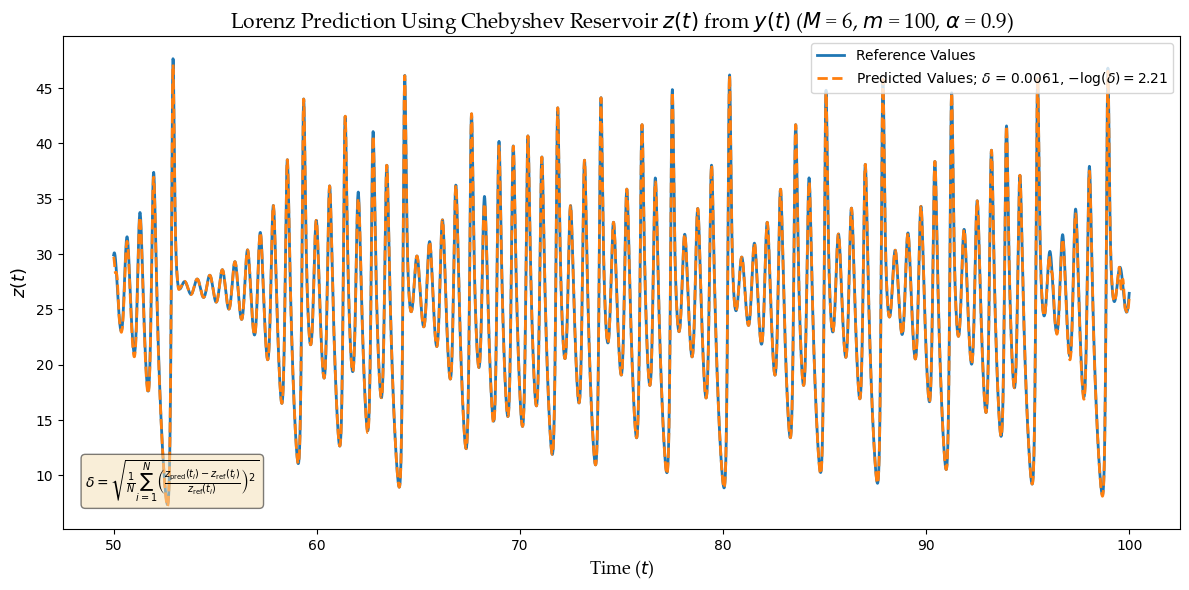

In [38]:
pred, v_test, t_test, log_del, delta = rc(100, 6, 0.9, 1, 2)

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$z(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Chebyshev Reservoir $z(t)$ from $y(t)$ ($M$ = 6, $m$ = 100, $\alpha$ = 0.9)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


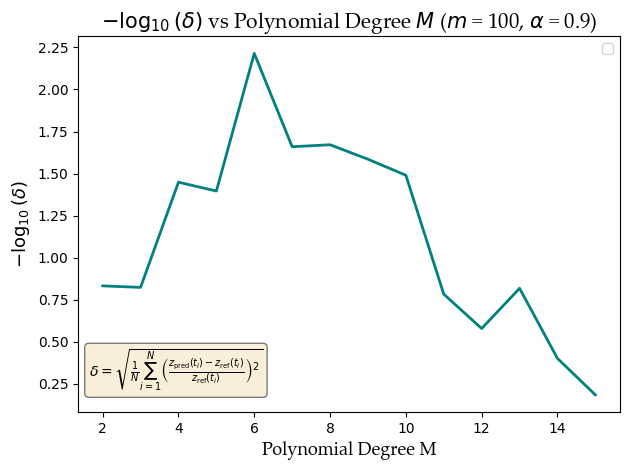

In [48]:
# delta vs M

M_values = range(2, 16)
m = 100
alpha = 0.9

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 1, 2)
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


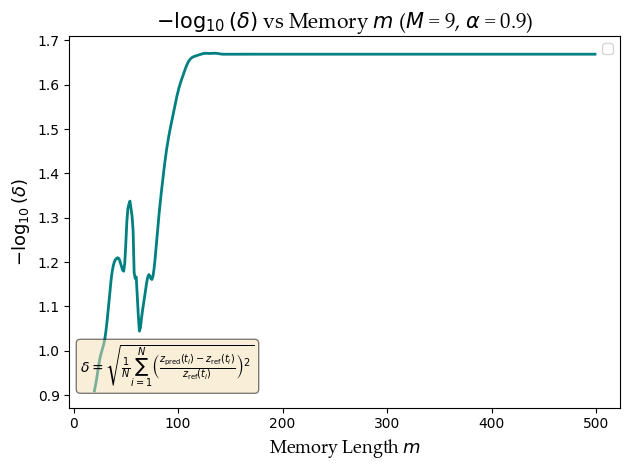

In [54]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'del_vs_m_zy.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


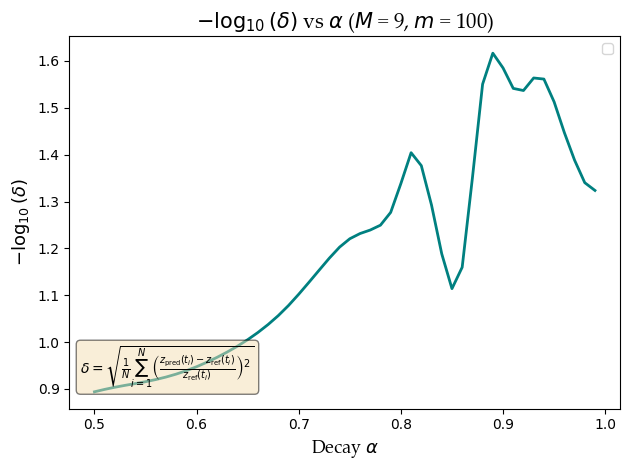

In [55]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'del_vs_a_zy.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### y(t) from z(t)

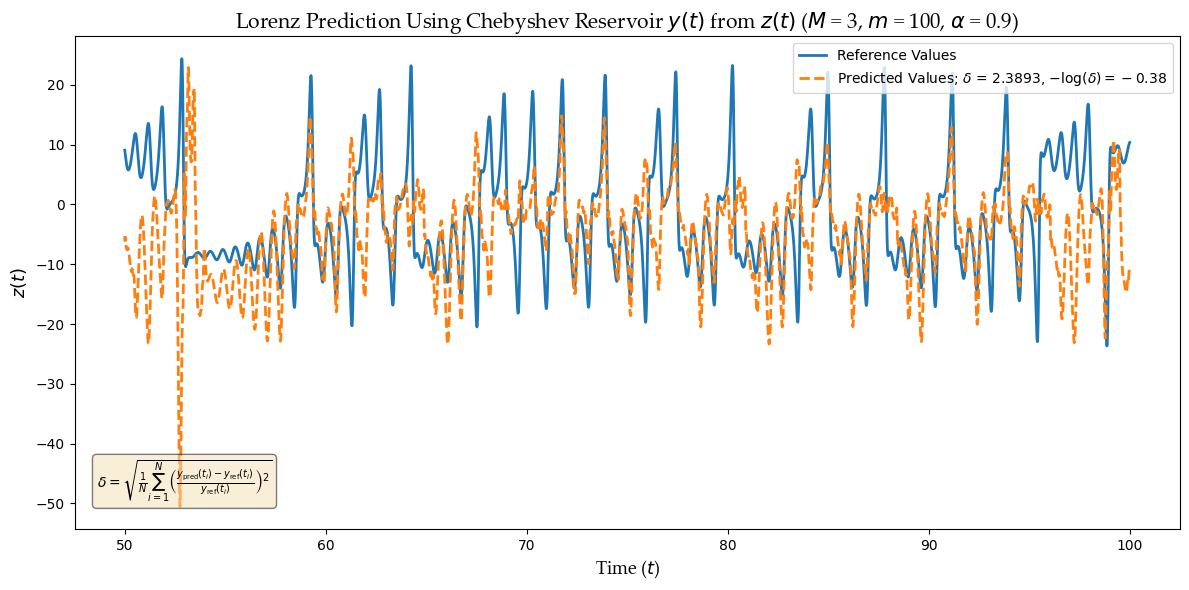

In [59]:
pred, v_test, t_test, log_del, delta = rc(100, 3, 0.9, 2, 1)

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$z(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Chebyshev Reservoir $y(t)$ from $z(t)$ ($M$ = 3, $m$ = 100, $\alpha$ = 0.9)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


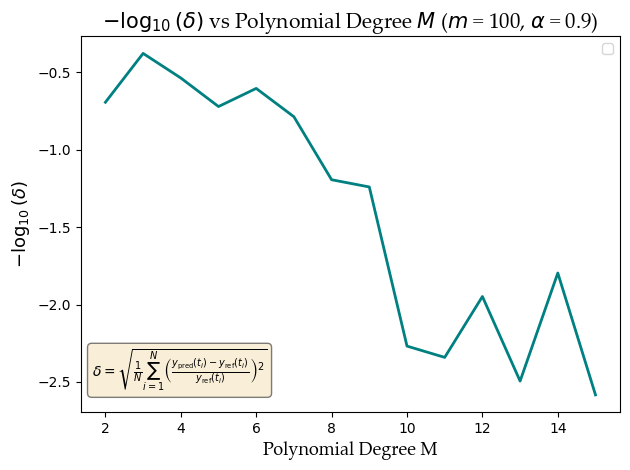

In [57]:
# delta vs M

M_values = range(2, 16)
m = 100
alpha = 0.9

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 2, 1)
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


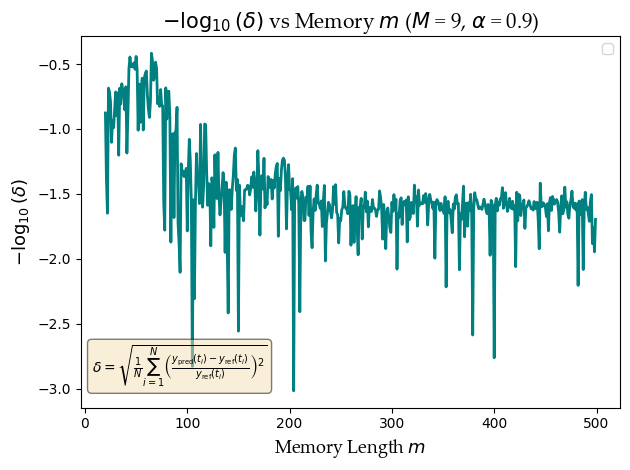

In [60]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'del_vs_m_yz.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


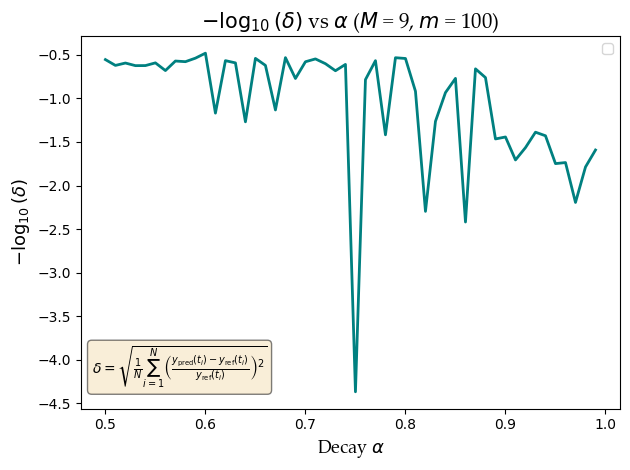

In [61]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'del_vs_a_yz.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

## Complete Parameter Sweep and $m$-$\alpha$ Relationship

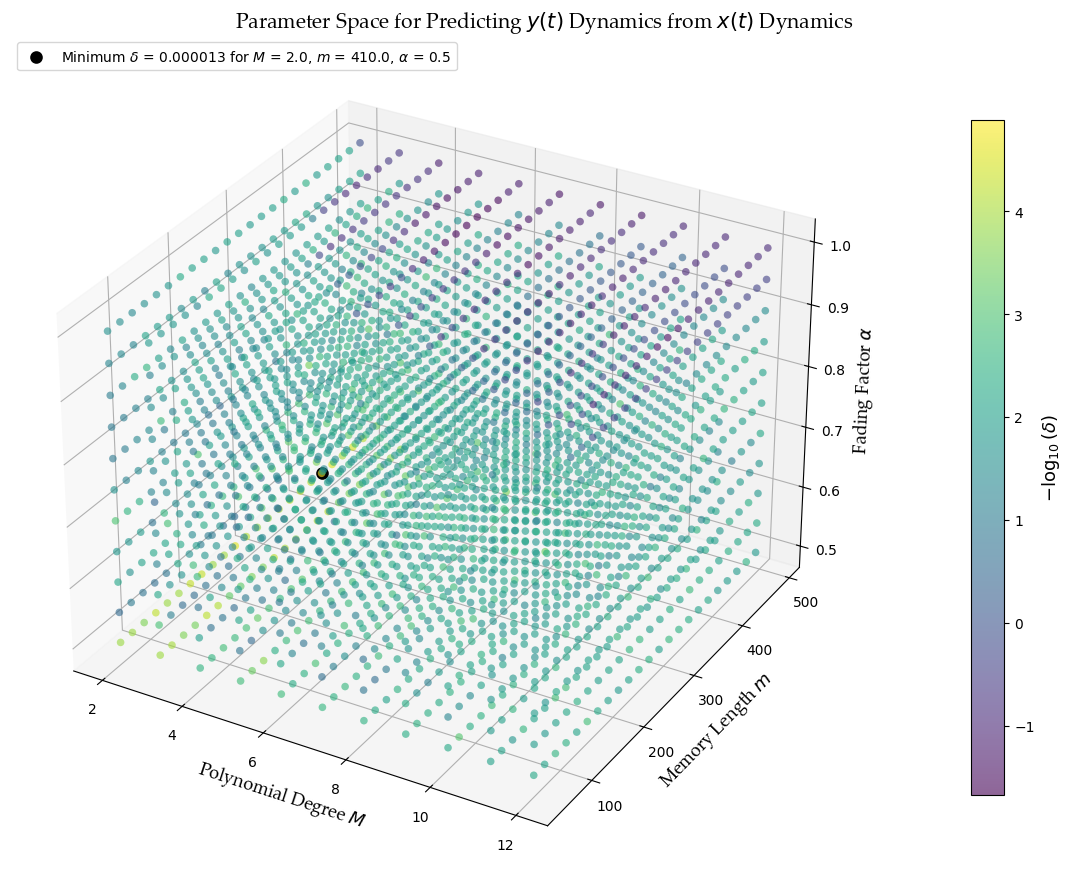

In [24]:
df = pd.read_csv('master_sweep_y_from_x.csv')

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['M'], df['m'], df['alpha'], 
                    c=df['log_delta'], cmap='viridis', 
                    s=30, alpha=0.6, edgecolors='none')

ax.set_xlabel(r'Polynomial Degree $M$', **hfont)
ax.set_ylabel(r'Memory Length $m$', **hfont)
ax.set_zlabel(r'Fading Factor $\alpha$', **hfont)
ax.set_title(r'Parameter Space for Predicting $y(t)$ Dynamics from $x(t)$ Dynamics', **csfont, loc = 'right')

cbar = plt.colorbar(scatter, ax = ax, pad = 0.1, shrink = 0.8)
cbar.set_label(r'$-\log_{10}(\delta)$', **hfont)

# minimum
best_idx = df['delta'].idxmin()
best = df.loc[best_idx]
ax.scatter(best['M'], best['m'], best['alpha'],
          c = 'k', s = 200, marker = '.', edgecolors = 'black', linewidth = 2,
          label= f'Minimum $\delta$ = {best["delta"]:.6f} for $M$ = {best["M"]}, $m$ = {best["m"]}, $\\alpha$ = {best["alpha"]}')
ax.legend(loc = 'upper left', fontsize=10)

plt.tight_layout()
plt.savefig('master_sweep_yx.png', dpi = 300, bbox_inches = 'tight')
plt.show()

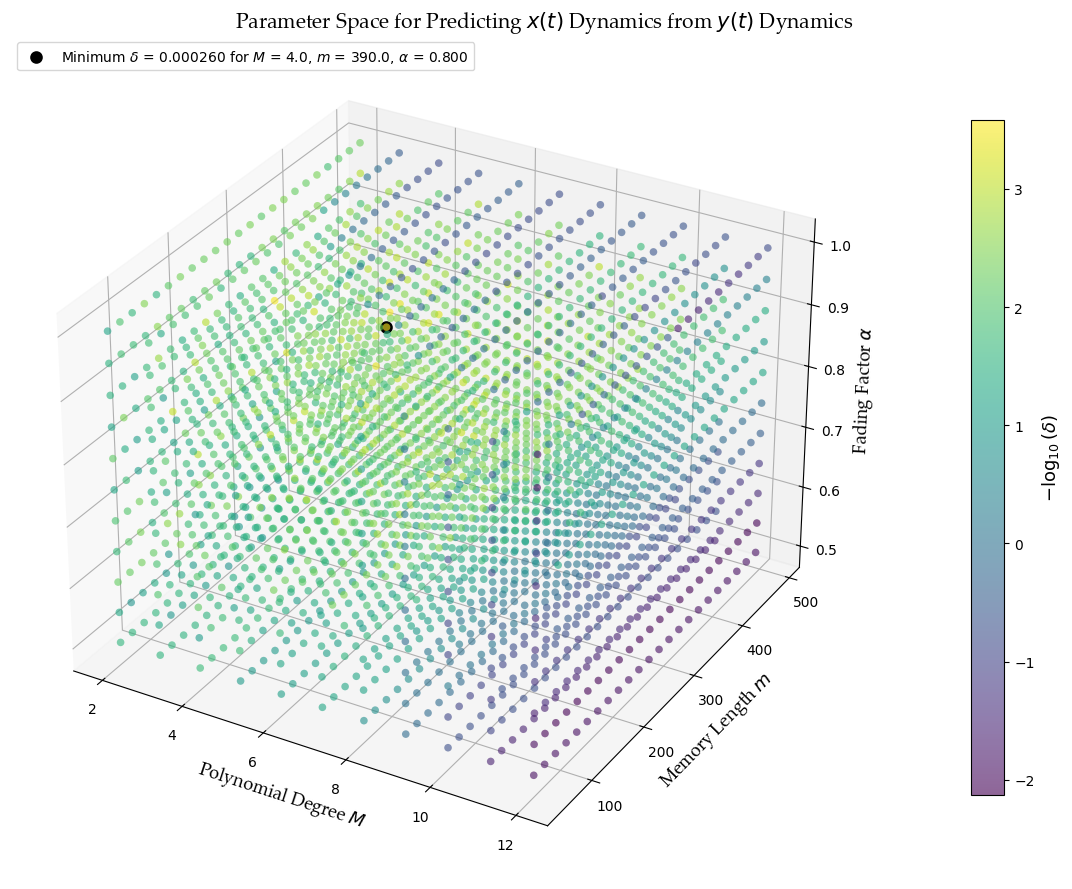

In [23]:
df = pd.read_csv('master_sweep_x_from_y.csv')

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['M'], df['m'], df['alpha'], 
                    c=df['log_delta'], cmap='viridis', 
                    s=30, alpha=0.6, edgecolors='none')

ax.set_xlabel(r'Polynomial Degree $M$', **hfont)
ax.set_ylabel(r'Memory Length $m$', **hfont)
ax.set_zlabel(r'Fading Factor $\alpha$', **hfont)
ax.set_title(r'Parameter Space for Predicting $x(t)$ Dynamics from $y(t)$ Dynamics', **csfont, loc = 'right')

cbar = plt.colorbar(scatter, ax = ax, pad = 0.1, shrink = 0.8)
cbar.set_label(r'$-\log_{10}(\delta)$', **hfont)

# minimum
best_idx = df['delta'].idxmin()
best = df.loc[best_idx]
ax.scatter(best['M'], best['m'], best['alpha'],
          c = 'k', s = 200, marker = '.', edgecolors = 'black', linewidth = 2,
          label= f'Minimum $\delta$ = {best["delta"]:.6f} for $M$ = {best["M"]}, $m$ = {best["m"]}, $\\alpha$ = {best["alpha"]:.3f}')
ax.legend(loc = 'upper left', fontsize=10)

plt.tight_layout()
plt.savefig('master_sweep_xy.png', dpi = 300, bbox_inches = 'tight')
plt.show()

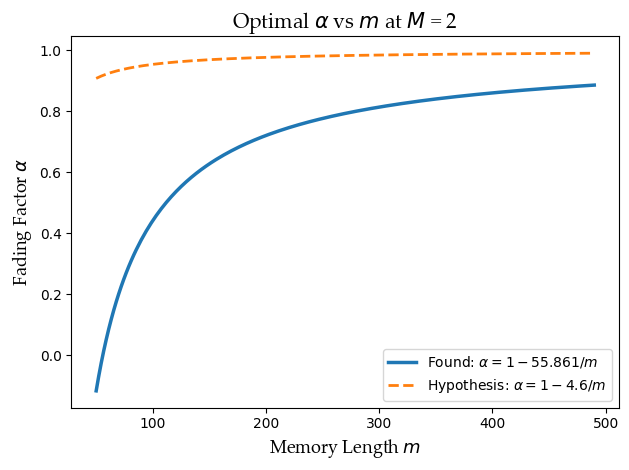


Fitted relationship: alpha = 1 - 55.861/m
Uncertainty: k = 55.861 ± 9.502
Theoretical: k = 4.6
Relative error: 1114.38%


In [37]:
df = pd.read_csv('master_sweep_y_from_x.csv')

# optimal M
best_idx = df['delta'].idxmin()
M_opt = int(df.loc[best_idx, 'M'])

df_fixed_M = df[df['M'] == M_opt].copy()

# for each m, optimal alpha
optimal_alpha_per_m = []

for m_val in sorted(df_fixed_M['m'].unique()):
    subset = df_fixed_M[df_fixed_M['m'] == m_val]
    min_idx = subset['delta'].idxmin()
    optimal_alpha_per_m.append({
        'm': m_val,
        'alpha_opt': subset.loc[min_idx, 'alpha'],
        'delta_min': subset.loc[min_idx, 'delta'],
        'log_delta_max': subset.loc[min_idx, 'log_delta']
    })

opt_df = pd.DataFrame(optimal_alpha_per_m)

# theoretical relationship
def model(m, k):
    return 1 - k / m

popt, pcov = curve_fit(model, opt_df['m'].values, opt_df['alpha_opt'].values, p0=[4.6])
k_fit = popt[0]
k_err = np.sqrt(pcov[0, 0])

fig, ax = plt.subplots()

m_smooth = np.linspace(opt_df['m'].min(), opt_df['m'].max(), 200)
alpha_fit = model(m_smooth, k_fit)
alpha_theory = model(m_smooth, 4.6)

ax.plot(m_smooth, alpha_fit, '-', linewidth=2.5,
       label=f'Found: $\\alpha = 1 - {k_fit:.3f}/m$')

ax.plot(m_smooth, alpha_theory, '--', linewidth=2,
       label='Hypothesis: $\\alpha = 1 - 4.6/m$')

# Fixed: use set_xlabel and set_ylabel (not set_zlabel)
ax.set_xlabel(r'Memory Length $m$', **hfont)
ax.set_ylabel(r'Fading Factor $\alpha$', **hfont)
ax.set_title(f'Optimal $\\alpha$ vs $m$ at $M$ = {M_opt}', **csfont)
ax.legend()

plt.tight_layout()
plt.savefig('m_alpha_relationship.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nFitted relationship: alpha = 1 - {k_fit:.3f}/m')
print(f'Uncertainty: k = {k_fit:.3f} ± {k_err:.3f}')
print(f'Theoretical: k = 4.6')
print(f'Relative error: {abs(k_fit - 4.6)/4.6 * 100:.2f}%')

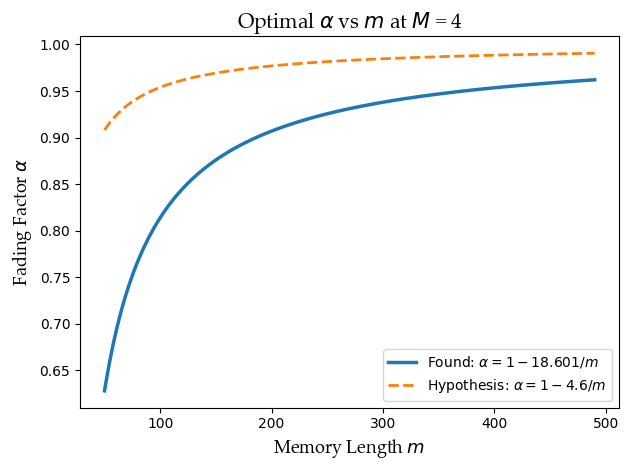


Fitted relationship: alpha = 1 - 18.601/m
Uncertainty: k = 18.601 ± 5.631
Theoretical: k = 4.6
Relative error: 304.36%


In [46]:
df = pd.read_csv('master_sweep_x_from_y.csv')

# optimal M
best_idx = df['delta'].idxmin()
M_opt = int(df.loc[best_idx, 'M'])

df_fixed_M = df[df['M'] == M_opt].copy()

# for each m, optimal alpha
optimal_alpha_per_m = []

for m_val in sorted(df_fixed_M['m'].unique()):
    subset = df_fixed_M[df_fixed_M['m'] == m_val]
    min_idx = subset['delta'].idxmin()
    optimal_alpha_per_m.append({
        'm': m_val,
        'alpha_opt': subset.loc[min_idx, 'alpha'],
        'delta_min': subset.loc[min_idx, 'delta'],
        'log_delta_max': subset.loc[min_idx, 'log_delta']
    })

opt_df = pd.DataFrame(optimal_alpha_per_m)

# theoretical relationship
def model(m, k):
    return 1 - k / m

popt, pcov = curve_fit(model, opt_df['m'].values, opt_df['alpha_opt'].values, p0=[4.6])
k_fit = popt[0]
k_err = np.sqrt(pcov[0, 0])

fig, ax = plt.subplots()

m_smooth = np.linspace(opt_df['m'].min(), opt_df['m'].max(), 200)
alpha_fit = model(m_smooth, k_fit)
alpha_theory = model(m_smooth, 4.6)

ax.plot(m_smooth, alpha_fit, '-', linewidth=2.5,
       label=f'Found: $\\alpha = 1 - {k_fit:.3f}/m$')

ax.plot(m_smooth, alpha_theory, '--', linewidth=2,
       label='Hypothesis: $\\alpha = 1 - 4.6/m$')

# Fixed: use set_xlabel and set_ylabel (not set_zlabel)
ax.set_xlabel(r'Memory Length $m$', **hfont)
ax.set_ylabel(r'Fading Factor $\alpha$', **hfont)
ax.set_title(f'Optimal $\\alpha$ vs $m$ at $M$ = {M_opt}', **csfont)
ax.legend()

plt.tight_layout()
plt.savefig('m_alpha_relationship.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nFitted relationship: alpha = 1 - {k_fit:.3f}/m')
print(f'Uncertainty: k = {k_fit:.3f} ± {k_err:.3f}')
print(f'Theoretical: k = 4.6')
print(f'Relative error: {abs(k_fit - 4.6)/4.6 * 100:.2f}%')

Global optimum: M=2, m=410, α=0.500, δ=0.000013


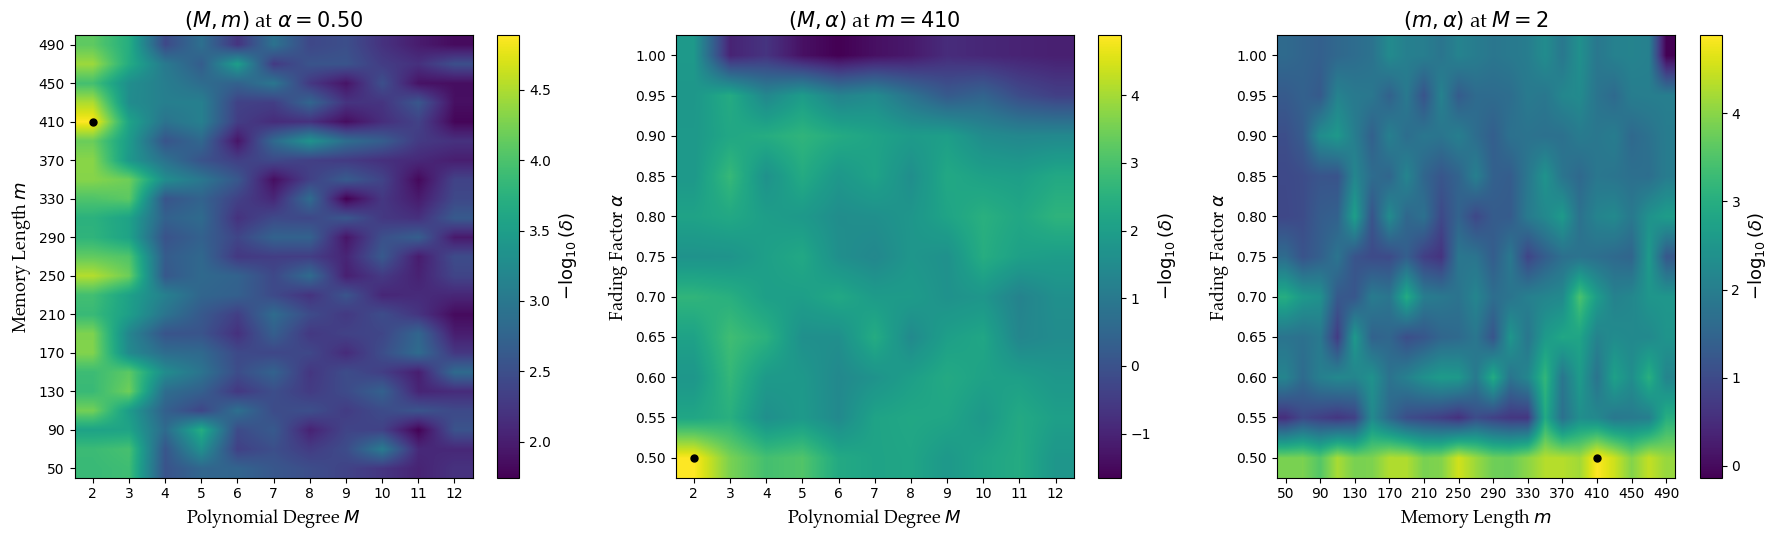

In [ ]:
df = pd.read_csv('master_sweep_y_from_x.csv')

# global optimum
best_idx = df['delta'].idxmin()
best = df.loc[best_idx]
M_opt = int(best['M'])
m_opt = int(best['m'])
alpha_opt = best['alpha']

print(f'Global optimum: $M$ = {M_opt}, $m$ = {m_opt}, $\alpha$ = {alpha_opt:.3f}, $\delta$ = {best['delta']:.6f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

alpha_vals = sorted(df['alpha'].unique())
alpha_closest = min(alpha_vals, key = lambda x: abs(x - alpha_opt)) # alpha closest to optimum

df_ma = df[df['alpha'] == alpha_closest].copy()
pivot_ma = df_ma.pivot_table(values = 'log_delta', index ='m', columns = 'M', aggfunc = 'mean')

im1 = axes[0].imshow(pivot_ma.values, aspect = 'auto', origin = 'lower', cmap = 'viridis', interpolation = 'bilinear')

axes[0].set_xticks(range(len(pivot_ma.columns)))
axes[0].set_xticklabels(pivot_ma.columns)

y_tick_step = max(1, len(pivot_ma.index)//10)
y_tick_indices = range(0, len(pivot_ma.index), y_tick_step)
axes[0].set_yticks(y_tick_indices)
axes[0].set_yticklabels([pivot_ma.index[i] for i in y_tick_indices])

axes[0].set_xlabel(r'Polynomial Degree $M$', **hfont)
axes[0].set_ylabel(r'Memory Length $m$', **hfont)
axes[0].set_title(f'$(M, m)$ at $\\alpha = {alpha_closest:.2f}$', **csfont)

if abs(alpha_closest - alpha_opt) < 0.02:
    try:
        m_idx = list(pivot_ma.index).index(m_opt)
        M_idx = list(pivot_ma.columns).index(M_opt)
        axes[0].scatter(M_idx, m_idx, c = 'k', s = 100, marker = '.')
    except ValueError:
        pass

cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label(r'$-\log_{10}(\delta)$', **hfont)

# M-alpha cross-section
m_vals = sorted(df['m'].unique())
m_closest = min(m_vals, key = lambda x: abs(x - m_opt))

df_malpha = df[df['m'] == m_closest].copy()
pivot_malpha = df_malpha.pivot_table(values = 'log_delta', index = 'alpha', columns = 'M', aggfunc = 'mean')

im2 = axes[1].imshow(pivot_malpha.values, aspect ='auto', origin = 'lower', cmap = 'viridis', interpolation = 'bilinear')

axes[1].set_xticks(range(len(pivot_malpha.columns)))
axes[1].set_xticklabels(pivot_malpha.columns)

y_tick_step = max(1, len(pivot_malpha.index)//10)
y_tick_indices = range(0, len(pivot_malpha.index), y_tick_step)
axes[1].set_yticks(y_tick_indices)
axes[1].set_yticklabels([f"{pivot_malpha.index[i]:.2f}" for i in y_tick_indices])

axes[1].set_xlabel(r'Polynomial Degree $M$', **hfont)
axes[1].set_ylabel(r'Fading Factor $\alpha$', **hfont)
axes[1].set_title(f'$(M, \\alpha)$ at $m = {m_closest}$', **csfont)

if abs(m_closest - m_opt) < 15:
    try:
        alpha_idx = min(range(len(pivot_malpha.index)), key = lambda i: abs(pivot_malpha.index[i] - alpha_opt))
        M_idx = list(pivot_malpha.columns).index(M_opt)
        axes[1].scatter(M_idx, alpha_idx, c = 'k', s = 100, marker = '.')
    except ValueError:
        pass

cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label(r'$-\log_{10}(\delta)$', **hfont)

# m-alpha cross-section
df_m_alpha = df[df['M'] == M_opt].copy()
pivot_m_alpha = df_m_alpha.pivot_table(values='log_delta', index='alpha', columns='m', aggfunc='mean')

im3 = axes[2].imshow(pivot_m_alpha.values, aspect = 'auto', origin = 'lower', cmap = 'viridis', interpolation = 'bilinear')

x_tick_step = max(1, len(pivot_m_alpha.columns)//10)
x_tick_indices = range(0, len(pivot_m_alpha.columns), x_tick_step)
axes[2].set_xticks(x_tick_indices)
axes[2].set_xticklabels([pivot_m_alpha.columns[i] for i in x_tick_indices])

y_tick_step = max(1, len(pivot_m_alpha.index)//10)
y_tick_indices = range(0, len(pivot_m_alpha.index), y_tick_step)
axes[2].set_yticks(y_tick_indices)
axes[2].set_yticklabels([f"{pivot_m_alpha.index[i]:.2f}" for i in y_tick_indices])

axes[2].set_xlabel(r'Memory Length $m$', **hfont)
axes[2].set_ylabel(r'Fading Factor $\alpha$', **hfont)
axes[2].set_title(f'$(m, \\alpha)$ at $M = {M_opt}$', **csfont)

try:
    m_idx = list(pivot_m_alpha.columns).index(m_opt)
    alpha_idx = min(range(len(pivot_m_alpha.index)), key = lambda i: abs(pivot_m_alpha.index[i] - alpha_opt))
    axes[2].scatter(m_idx, alpha_idx, c='k', s=100, marker='.')
except ValueError:
    pass

cbar3 = plt.colorbar(im3, ax = axes[2])
cbar3.set_label(r'$-\log_{10}(\delta)$', **hfont)

plt.tight_layout()
plt.show()

## Tent Map Reservoir Results

### y(t) from x(t)

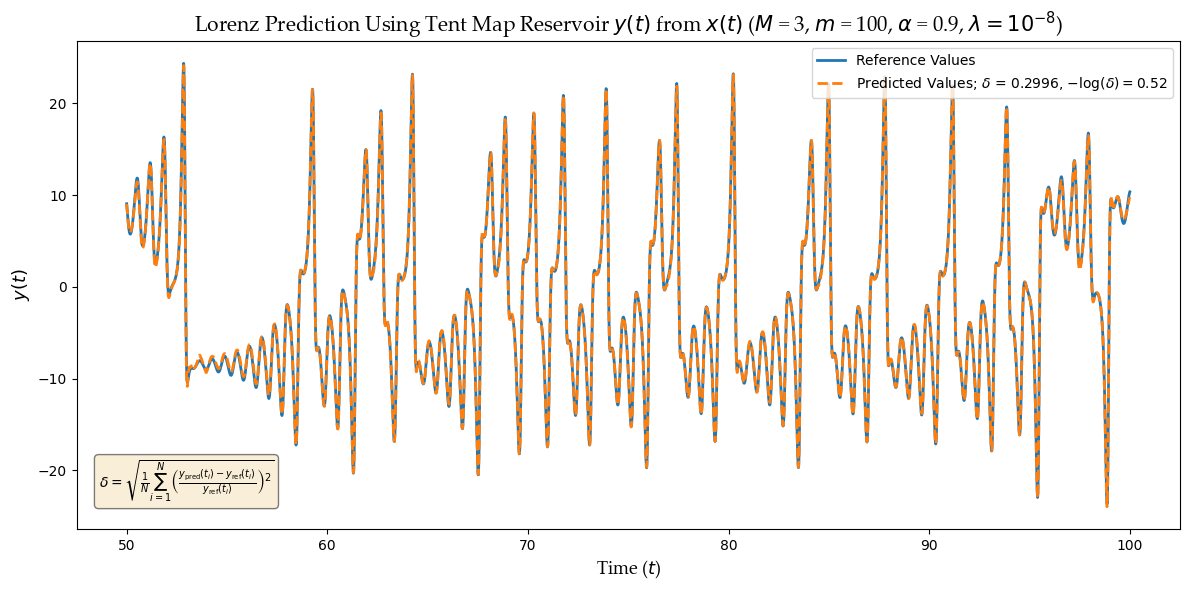

In [ ]:
# (m, M, alpha, input index, output index)
pred, v_test, t_test, log_del, delta = rc(100, 3, 0.9, 0, 1, res = 'tent')

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$y(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Tent Map Reservoir $y(t)$ from $x(t)$ ($M$ = 3, $m$ = 100, $\alpha$ = 0.9, $\lambda = 10^{-8}$)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


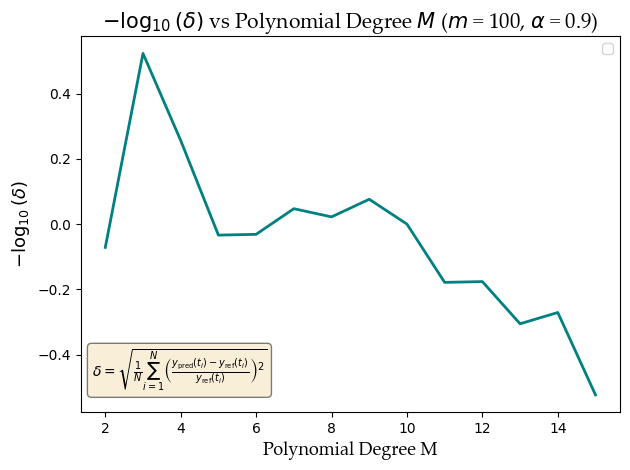

In [21]:
# delta vs M

M_values = range(2, 16)
m = 100
alpha = 0.9

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 0, 1, res = 'tent')
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


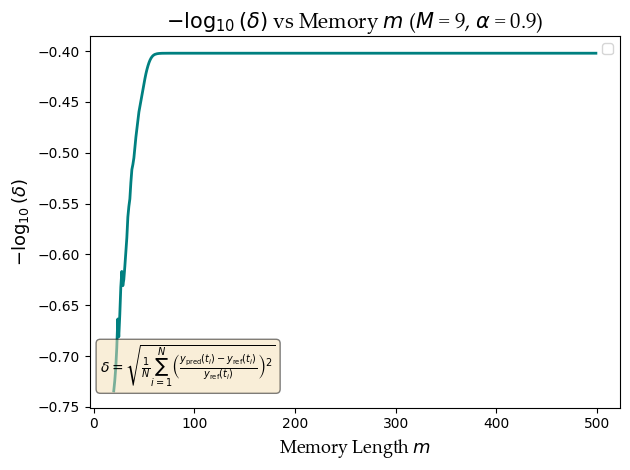

In [39]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'Tent/tnt_del_vs_m_yx.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


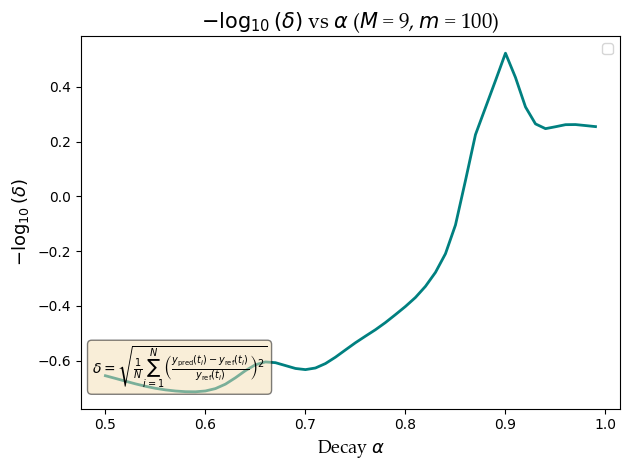

In [40]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'Tent/tnt_del_vs_a_yx.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})}{y_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### x(t) from y(t)

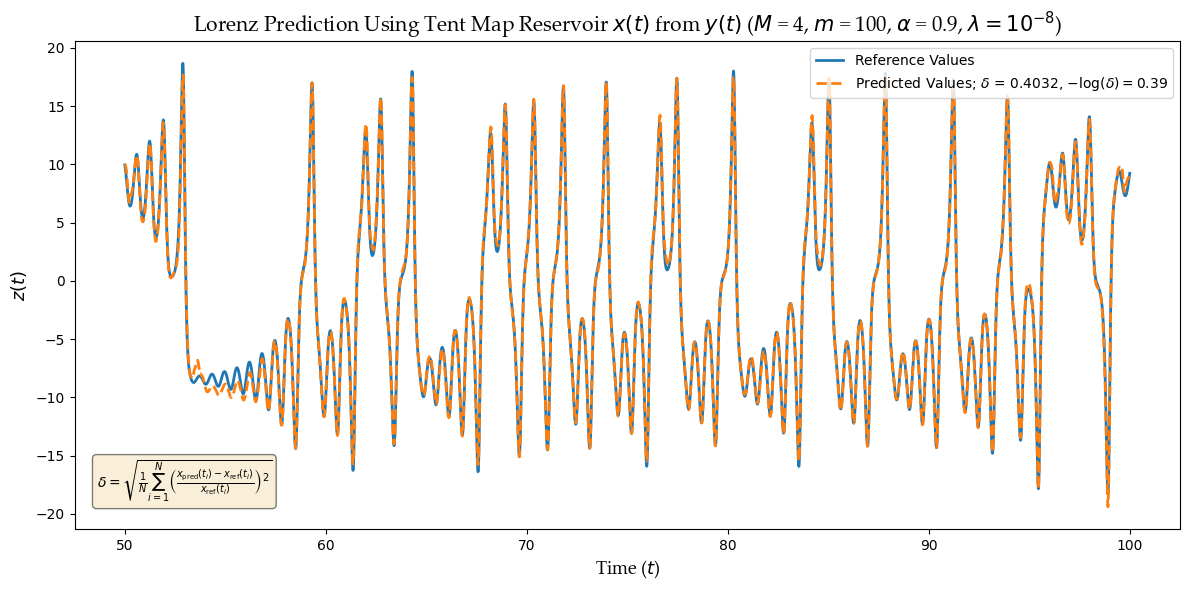

In [12]:
# running
# (m, M, alpha, input index, output index)
pred, v_test, t_test, log_del, delta = rc(100, 4, 0.9, 1, 0, res = 'tent')

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$z(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Tent Map Reservoir $x(t)$ from $y(t)$ ($M$ = 4, $m$ = 100, $\alpha$ = 0.9, $\lambda = 10^{-8}$)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


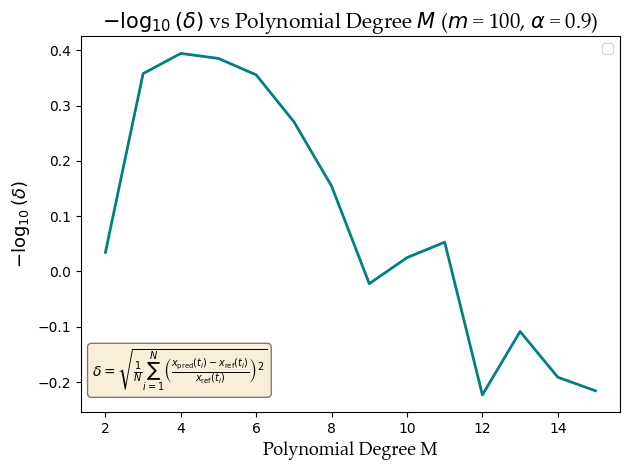

In [13]:
# delta vs M

M_values = range(2, 16)
m = 100
alpha = 0.9

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 1, 0, res = 'tent')
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


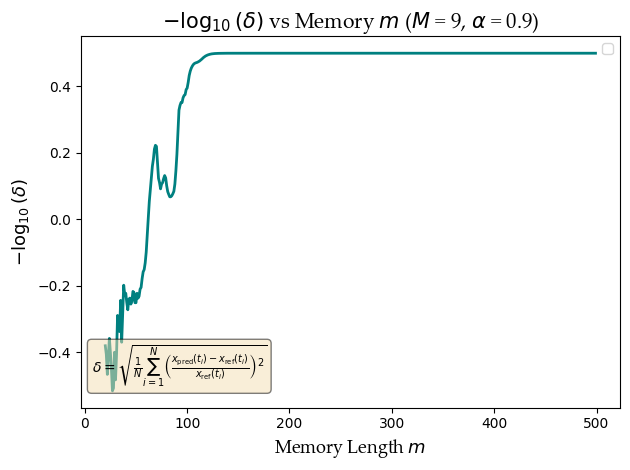

In [41]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'Tent/tnt_del_vs_m_xy.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


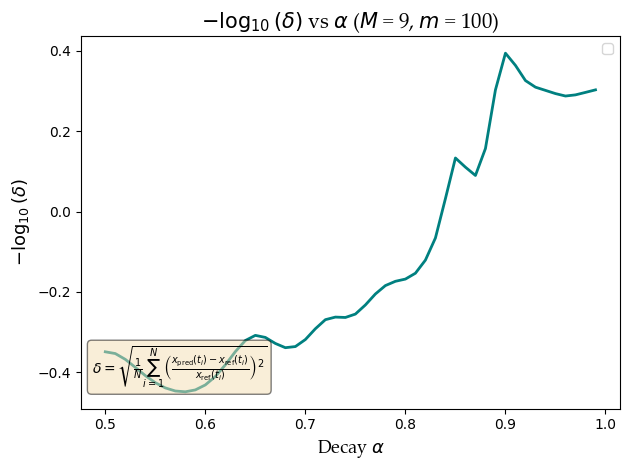

In [42]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'Tent/tnt_del_vs_a_xy.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### x(t) from z(t)

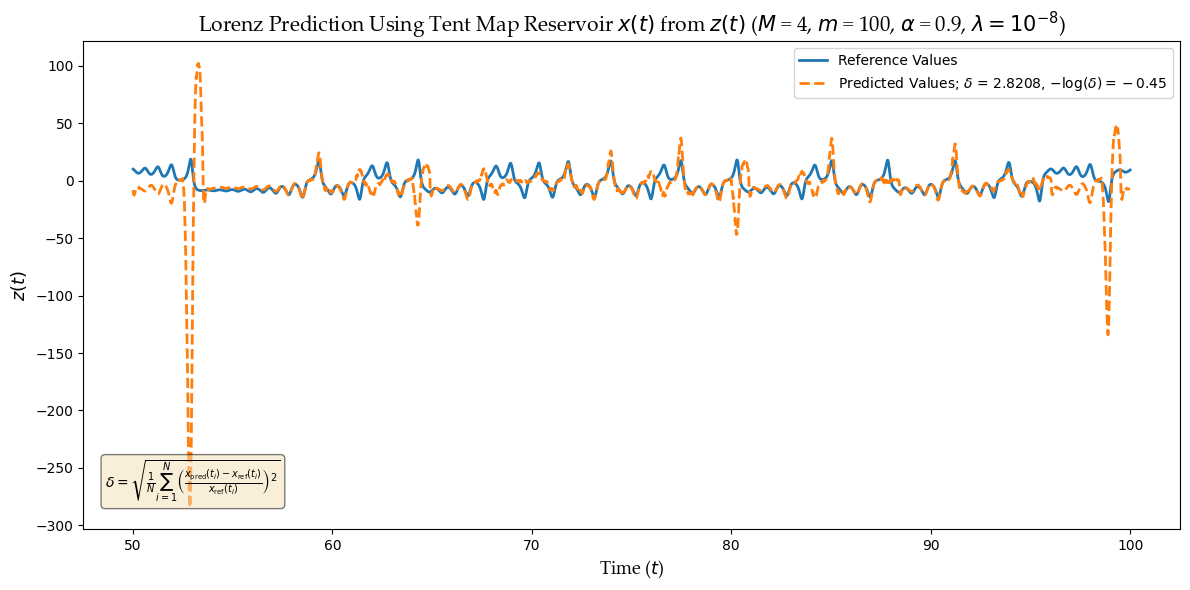

In [22]:
# running
# (m, M, alpha, input index, output index)
pred, v_test, t_test, log_del, delta = rc(100, 4, 0.9, 2, 0, res = 'tent')

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$z(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Tent Map Reservoir $x(t)$ from $z(t)$ ($M$ = 4, $m$ = 100, $\alpha$ = 0.9, $\lambda = 10^{-8}$)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


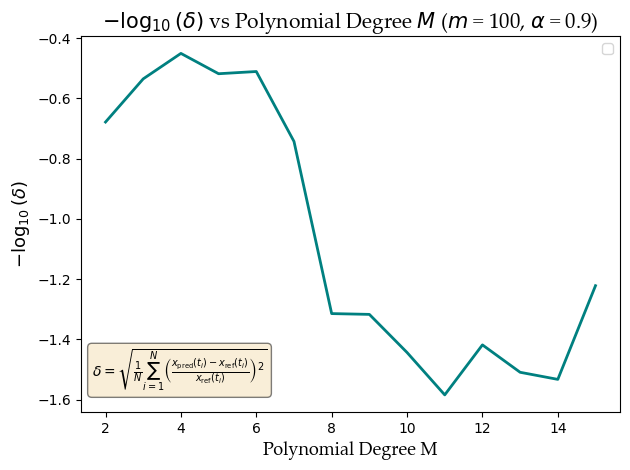

In [23]:
# delta vs M

M_values = range(2, 16)
m = 100
alpha = 0.9

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 2, 0, res = 'tent')
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


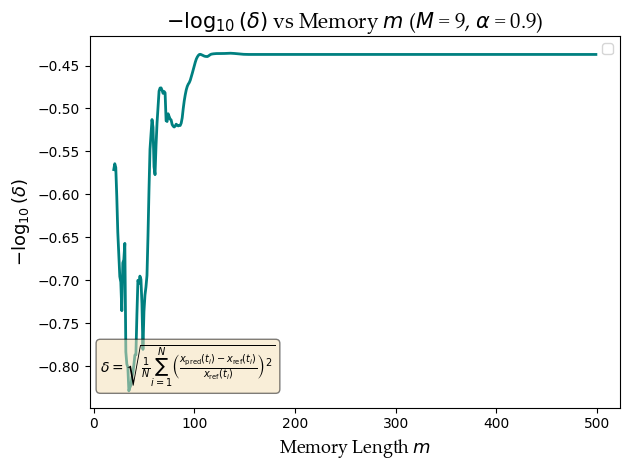

In [43]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'Tent/tnt_del_vs_m_xz.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


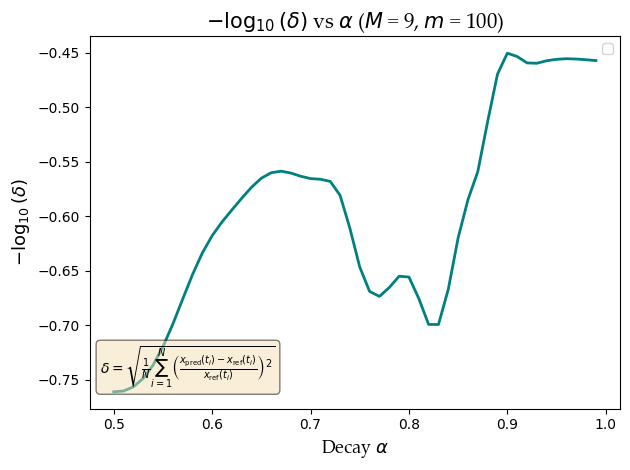

In [44]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'Tent/tnt_del_vs_a_xz.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})}{x_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### z(t) from x(t)

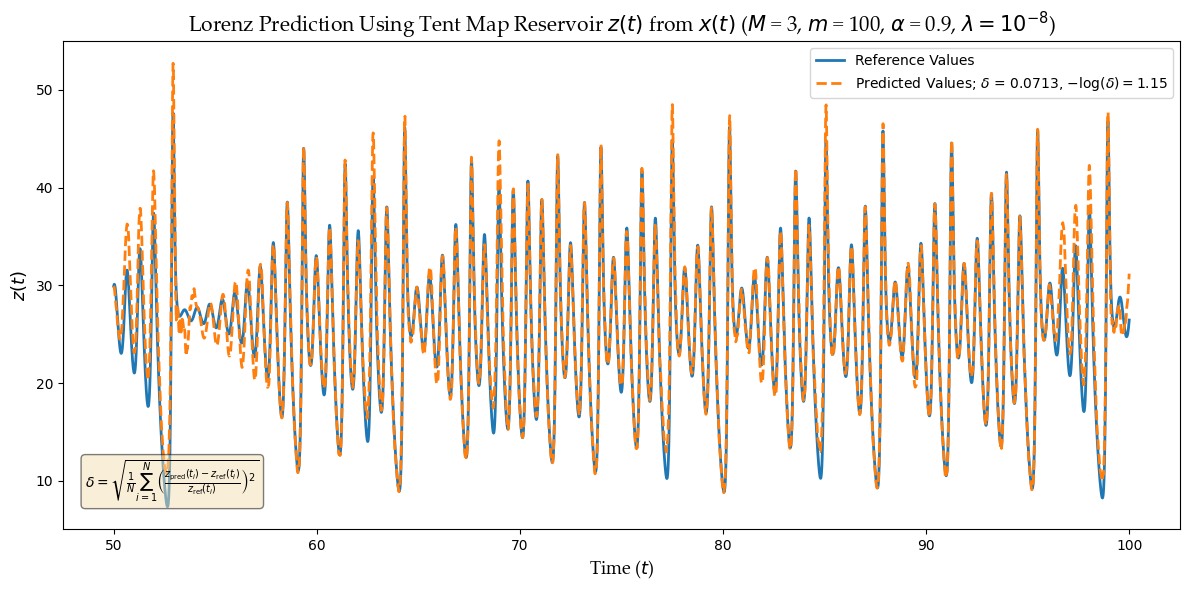

In [26]:
# running
# (m, M, alpha, input index, output index)
pred, v_test, t_test, log_del, delta = rc(100, 4, 0.9, 0, 2, res = 'tent')

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(t_test, v_test, '-', linewidth = 2, label ='Reference Values')
ax.plot(t_test, pred, '--', linewidth = 2, label = f'Predicted Values; $\delta$ = {round(delta, 4)}, $-\log(\delta) = {round(log_del, 2)}$')
ax.set_xlabel(r'Time ($t$)', **hfont)
ax.set_ylabel(r'$z(t)$', **hfont)
ax.set_title(r'Lorenz Prediction Using Tent Map Reservoir $z(t)$ from $x(t)$ ($M$ = 3, $m$ = 100, $\alpha$ = 0.9, $\lambda = 10^{-8}$)', **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


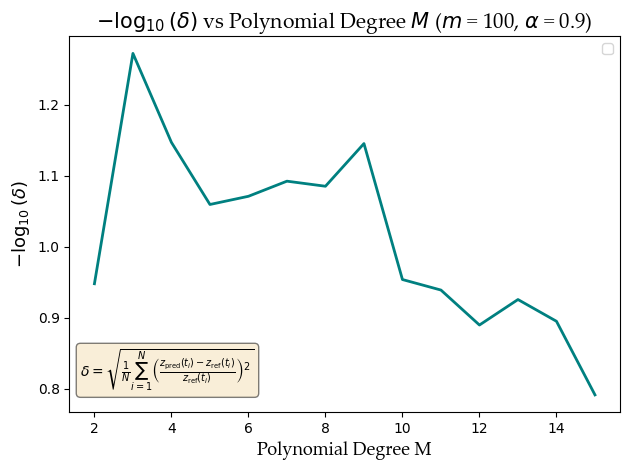

In [25]:
# delta vs M

M_values = range(2, 16)
m = 100
alpha = 0.9

delta_M = []
for i in M_values:
    pred, v_test, t_test, log_del, delta = rc(m, i, alpha, 0, 2, res = 'tent')
    delta_M.append(delta)

fig, ax = plt.subplots()
ax.plot(M_values, -np.log10(delta_M), linewidth = 2, color = 'teal')
ax.set_xlabel('Polynomial Degree M', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Polynomial Degree $M$ ($m$ = 100, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


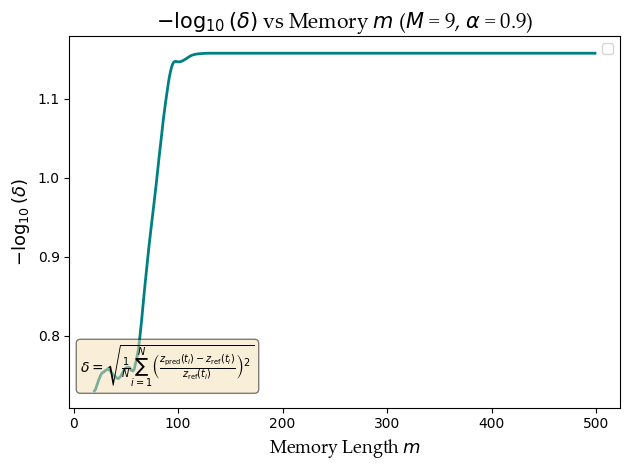

In [46]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'Tent/tnt_del_vs_m_zx.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ ($M$ = 9, $\alpha$ = 0.9)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


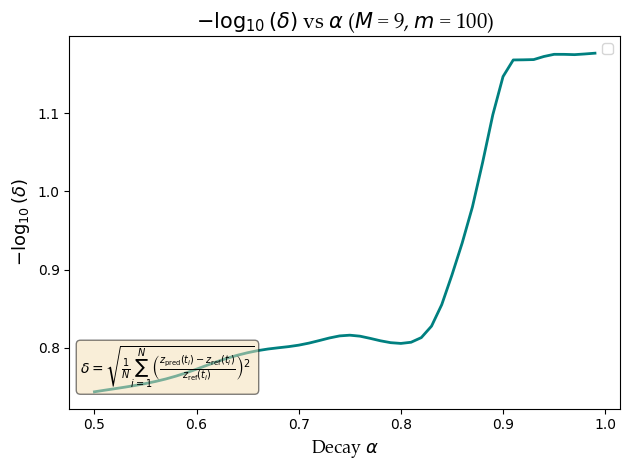

In [45]:
# a_values = range(0.5, 1.0, 0.01)
# M = 9
# m = 100

# delta_a = []

# for i in a_values:
#     pred, v_test, t_test, log_del, delta = rc(m, M, i, 0, 2)
#     delta_a.append(i)

df = pd.read_csv(f'Tent/tnt_del_vs_a_zx.csv')
fig, ax = plt.subplots()
ax.plot(df['alpha'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel(r'Decay $\alpha$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs $\alpha$ ($M$ = 9, $m$ = 100)', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(\frac{z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})}{z_{\text{ref}}(t_{i})}\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

## Logistic Reservoir Results (From Arun et. al)

### Error x(t) from y(t)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


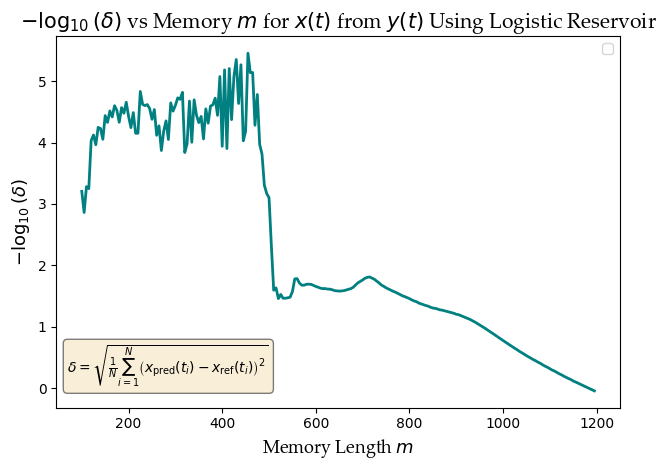

In [42]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'C:/Users/Sahaana V/Desktop/ASP/Final_Analysis/PredErr_Logistic/logistic_error_vs_memory_xy.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ for $x(t)$ from $y(t)$ Using Logistic Reservoir', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### Error y(t) from x(t)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


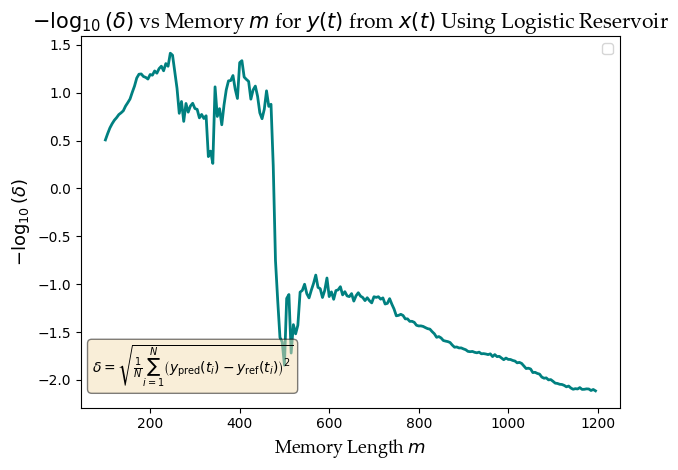

In [47]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'C:/Users/Sahaana V/Desktop/ASP/Final_Analysis/PredErr_Logistic/logistic_error_vs_memory_yx.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ for $y(t)$ from $x(t)$ Using Logistic Reservoir', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(y_{\text{pred}}(t_{i}) - y_{\text{ref}}(t_{i})\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### Error z(t) from x(t)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


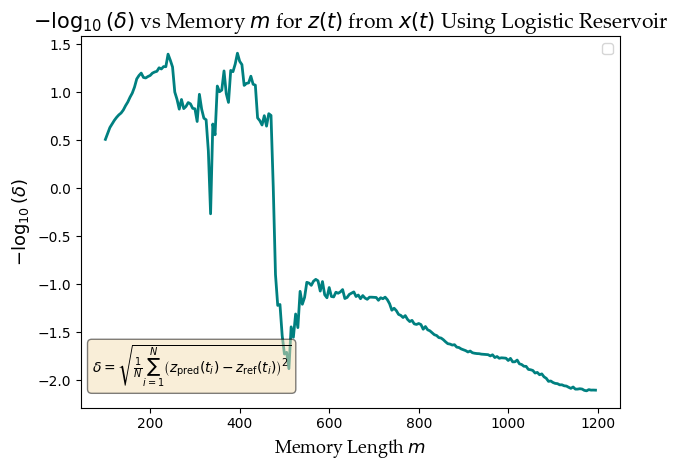

In [44]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'C:/Users/Sahaana V/Desktop/ASP/Final_Analysis/PredErr_Logistic/logistic_error_vs_memory_zx.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ for $z(t)$ from $x(t)$ Using Logistic Reservoir', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(z_{\text{pred}}(t_{i}) - z_{\text{ref}}(t_{i})\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

### Error x(t) from z(t)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


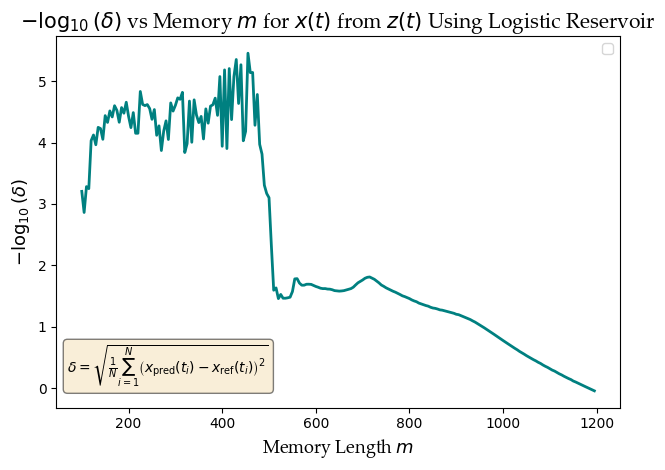

In [45]:
# m_values = range(20, 500)
# delta_m = []
# for i in m_values:
#     pred, v_test, t_test, log_del, delta = rc(i, 9, alpha, 0, 2)
#     delta_m.append(delta)

df = pd.read_csv(f'C:/Users/Sahaana V/Desktop/ASP/Final_Analysis/PredErr_Logistic/logistic_error_vs_memory_xz.csv')
fig, ax = plt.subplots()
ax.plot(df['m'], -np.log10(df['delta']), linewidth = 2, color = 'teal')
ax.set_xlabel('Memory Length $m$', **hfont)
ax.set_ylabel(r'$-\log_{10}(\delta)$', **hfont)
ax.set_title(r'$-\log_{10}(\delta)$ vs Memory $m$ for $x(t)$ from $z(t)$ Using Logistic Reservoir', fontsize = 14, **csfont)
props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5)
ax.text(0.02, 0.05, r'$\delta = \sqrt{\frac{1}{N}\sum_{i = 1}^{N} \left(x_{\text{pred}}(t_{i}) - x_{\text{ref}}(t_{i})\right)^2}$', bbox = props, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left')
ax.legend(loc = 'upper right')
plt.tight_layout()
plt.show()